In [3]:
import pandas as pd

# load the dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\Basic codes in the WQU\Yeast Protein Localization Classification\yeast.csv")


# show the first few rows
print(df.head())

    mcg   gvh   alm   mit  erl  pox   vac   nuc localization_site
0  0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22               MIT
1  0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22               MIT
2  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22               MIT
3  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22               NUC
4  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22               MIT


In [5]:
# check dataset shape
print(f"Shape of dataset: {df.shape}")


# check column datatypes
print(df.dtypes)


# check the columns in a list
print(f"Feature columns in a list:, {df.columns.tolist()[:-1]}")

Shape of dataset: (1484, 9)
mcg                  float64
gvh                  float64
alm                  float64
mit                  float64
erl                  float64
pox                  float64
vac                  float64
nuc                  float64
localization_site        str
dtype: object
Feature columns in a list:, ['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']


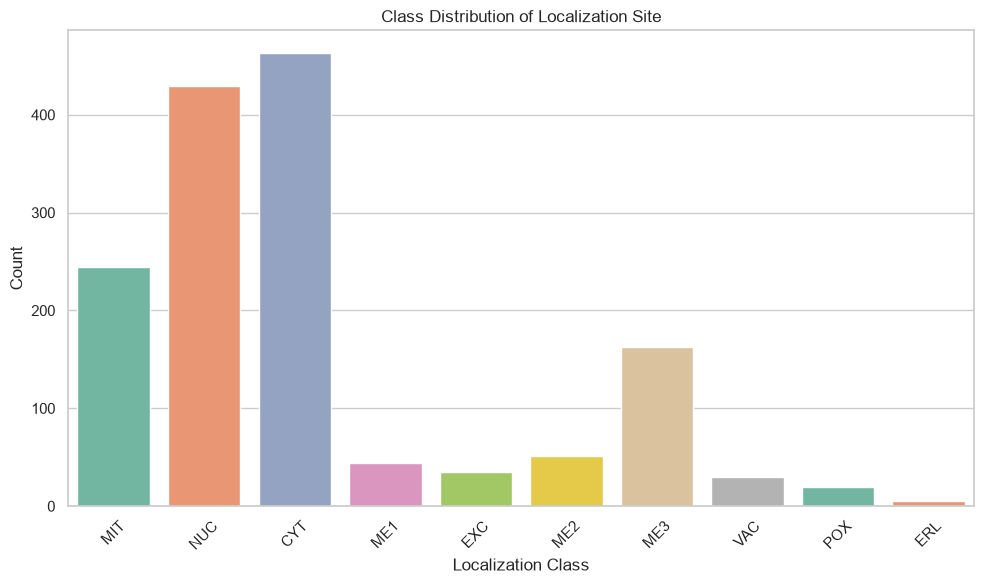

In [6]:
# The class distribution

import matplotlib.pyplot as plt
import seaborn as sns


# set seaborn style
sns.set_theme(style="whitegrid")


# plot class distribution
plt.figure(figsize=(10, 6))


sns.countplot(x="localization_site", data=df, palette="Set2", hue="localization_site")

plt.title("Class Distribution of Localization Site")
plt.xlabel("Localization Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The class imbalance is apparent in classes like MIT, NUC and CYT. This leads to bias during lead. 

**SOLUTION**  ---->  Further EDA to understand how features are distributed

In [7]:
# check for the class distribution

class_counts = df["localization_site"].value_counts().to_dict()

print("class distribution:", class_counts)

class distribution: {'CYT': 463, 'NUC': 429, 'MIT': 244, 'ME3': 163, 'ME2': 51, 'ME1': 44, 'EXC': 35, 'VAC': 30, 'POX': 20, 'ERL': 5}


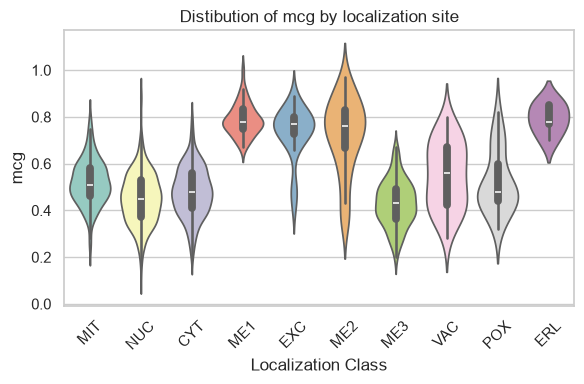

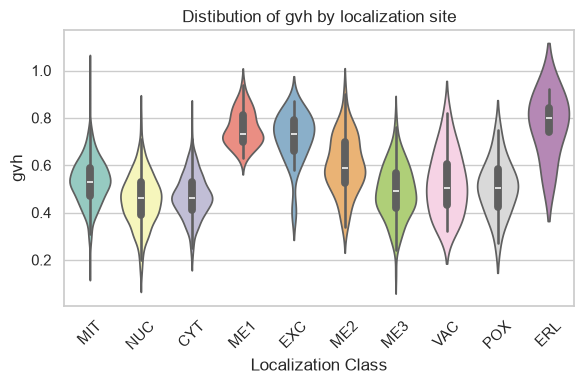

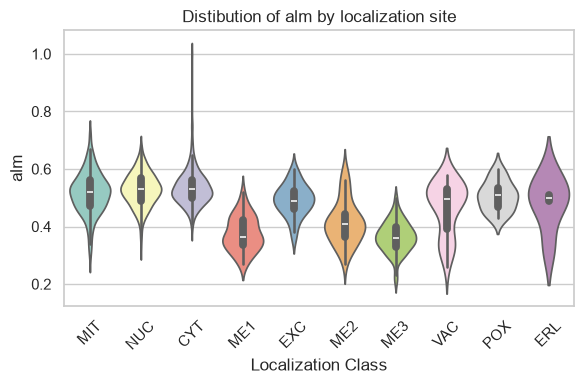

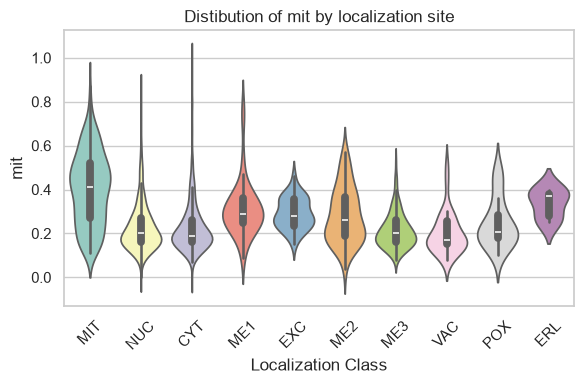

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


# select a few features to plot
features_to_plot = ['mcg', 'gvh', 'alm', 'mit']


# set style
sns.set_theme(style='whitegrid')
# plot feature distributions by class using hue for future compatibility

for f in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        x='localization_site',
        y=f,
        hue='localization_site',
        data=df,
        inner='box',
        palette="Set3",
        legend=False,    #prevents duplicate legend
    )
    plt.title(f"Distibution of {f} by localization site")
    plt.xlabel("Localization Class")
    plt.ylabel(f)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

These show that some classes like `mcg` and `gvh` have clear distinctions in the distribution of some classes like `ME1`, `ME2` and `ERL`, where they appear to be tightly packed and significantly shifted from others. 

`alm` show a fairly consistent stability across classes, but with subtle differences. 

`mit` also shows notable variation across all the classes representated.

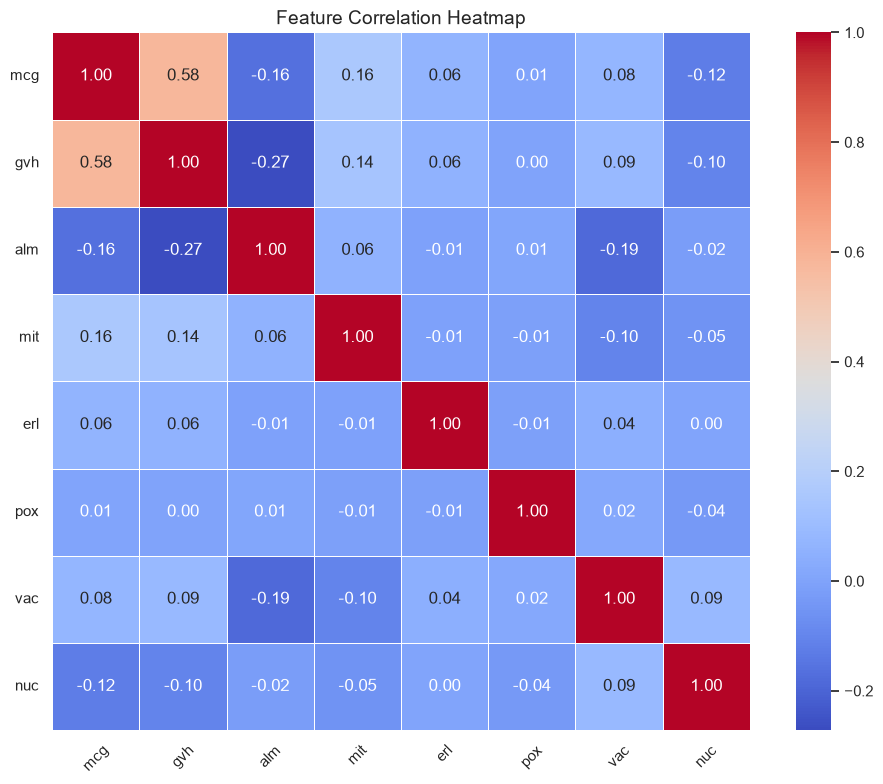

In [10]:
# check for correlation

feature_cols = ['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']
corr_matrix = df[feature_cols].corr()


# plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidth=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This is good signal, as most features have low to very low correlation. There is unlikelihood of facing sever multicollinearity.

`mcg` and `gvh` both have the highest observed correlation, as both relate to signal sequence recognition.



In [13]:
# Label Encoding (not ordinal encoding (used for independent variables))
from sklearn.preprocessing import LabelEncoder
import pandas as pd


# copy the original dataframe to avoid modifying it in place
df_encoded = df.copy()

# Label Encoding
label_encoder = LabelEncoder()
df_encoded['label_encoded'] = label_encoder.fit_transform(df_encoded['localization_site'])


print("Label Encoded Classes:")
print(df_encoded[['localization_site', 'label_encoded']].head(10))

Label Encoded Classes:
  localization_site  label_encoded
0               MIT              6
1               MIT              6
2               MIT              6
3               NUC              7
4               MIT              6
5               CYT              0
6               MIT              6
7               NUC              7
8               MIT              6
9               CYT              0


In [15]:
df_encoded.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,localization_site,label_encoded
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT,6
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT,6
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT,6
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC,7
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT,6


In [22]:
X = df_encoded.drop(columns=["localization_site", "label_encoded"])
X.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22


In [35]:
y = df_encoded.iloc[:, -1]

# convert pandas series into numpy array for tensor conversion process
y_array = y.to_numpy()
y_array[:5]

array([6, 6, 6, 7, 6])

In [36]:
from  sklearn.preprocessing import StandardScaler

# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
from sklearn.model_selection import train_test_split

# Train/test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_scaled, y_array, test_size=0.2, random_state=42, stratify=y_array
)


In [38]:
X_train_np[:5]

array([[-8.02323210e-01, -1.04883677e+00, -1.96250749e+00,
        -2.27549494e-01, -9.75900073e-02, -9.91313957e-02,
         3.48140558e-01, -1.52172423e-01],
       [-1.31233016e+00,  1.45353264e+00,  1.15029865e-01,
        -7.38306656e-01, -9.75900073e-02,  1.08714097e+01,
         8.67377329e-01, -5.27919305e-01],
       [ 5.81981357e-01,  2.42708728e-01, -1.96250749e+00,
        -8.65356762e-03, -9.75900073e-02, -9.91313957e-02,
         1.75061634e-01, -5.27919305e-01],
       [ 2.18486033e+00,  2.58363495e+00, -1.15457630e+00,
         3.56172976e-01, -9.75900073e-02, -9.91313957e-02,
         1.21353518e+00, -2.46109143e-01],
       [-8.75181345e-01, -1.53316634e+00,  1.03837980e+00,
        -5.19410729e-01, -9.75900073e-02, -9.91313957e-02,
        -6.90332985e-01, -5.27919305e-01]])

In [45]:
import torch

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
y_test = torch.tensor(y_test_np, dtype=torch.long)


print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Number of classes:", len(label_encoder.classes_))

Train set size: torch.Size([1187, 8])
Test set size: torch.Size([297, 8])
Number of classes: 10


In [47]:
import torch
import torch.nn as nn 


# define the model using nn.Sequential
model = nn.Sequential(
    nn.Linear(8, 16),    # input layer to hidden layer
    nn.ReLU(),           # non-linearity
    nn.Linear(16, 10)    # hidden layer to output layer (10 classes)
)

print(model)

Sequential(
  (0): Linear(in_features=8, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
)


In [48]:
# setup the training loop

# 1. forward pass
# 2. loss computation
# 3. backward pass
# 4. parameter update
# loops


# loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# training loop
epochs = 200
train_losses = []
train_accuracies = []


for epoch in range(epochs):
    # forward pass
    logits = model(X_train)
    loss = criterion(logits, y_train)


    # backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    # record loss
    train_losses.append(loss.item())


    # compute training accuracy
    preds = torch.argmax(logits, dim=1)
    correct = (preds == y_train).sum().item()
    accuracy = correct / len(y_train)
    train_accuracies.append(accuracy)

    # print every 10 seconds
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}, Accuracy = {accuracy*100:.2f}%")

Epoch 10: Loss = 1.7806, Accuracy = 35.72%
Epoch 20: Loss = 1.3952, Accuracy = 46.00%
Epoch 30: Loss = 1.2128, Accuracy = 54.42%
Epoch 40: Loss = 1.1270, Accuracy = 58.47%


Epoch 50: Loss = 1.0768, Accuracy = 59.73%
Epoch 60: Loss = 1.0474, Accuracy = 60.83%
Epoch 70: Loss = 1.0269, Accuracy = 61.33%
Epoch 80: Loss = 1.0109, Accuracy = 62.17%
Epoch 90: Loss = 0.9981, Accuracy = 62.01%
Epoch 100: Loss = 0.9877, Accuracy = 62.26%
Epoch 110: Loss = 0.9786, Accuracy = 62.93%
Epoch 120: Loss = 0.9703, Accuracy = 63.02%
Epoch 130: Loss = 0.9631, Accuracy = 63.52%
Epoch 140: Loss = 0.9569, Accuracy = 63.35%
Epoch 150: Loss = 0.9515, Accuracy = 63.52%
Epoch 160: Loss = 0.9463, Accuracy = 63.77%
Epoch 170: Loss = 0.9415, Accuracy = 63.61%
Epoch 180: Loss = 0.9378, Accuracy = 63.94%
Epoch 190: Loss = 0.9346, Accuracy = 64.11%
Epoch 200: Loss = 0.9314, Accuracy = 63.77%


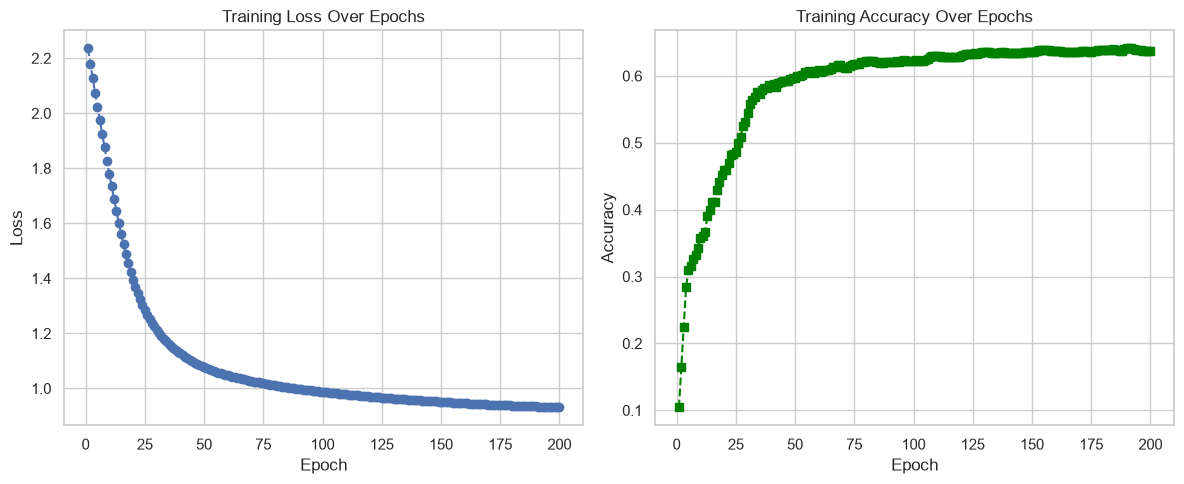

In [49]:
# train the loss and accuracies
import matplotlib.pyplot as plt


# plot training loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', linestyle='--')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)


# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, marker='s', linestyle='--', color='green')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


The loss decreases steadily, especially in the early epochs. At about 100 epochs, it begins to flatten out. 

For the accuracy, it rises quickly in the first few epochs, showing that it is learning rapidly at the start. At about 65 epoch, it begins to stabilize.


Both the accuracy and the loss are consistent in their messge. The model is learning and getting better.

Test Accuracy: 0.5892


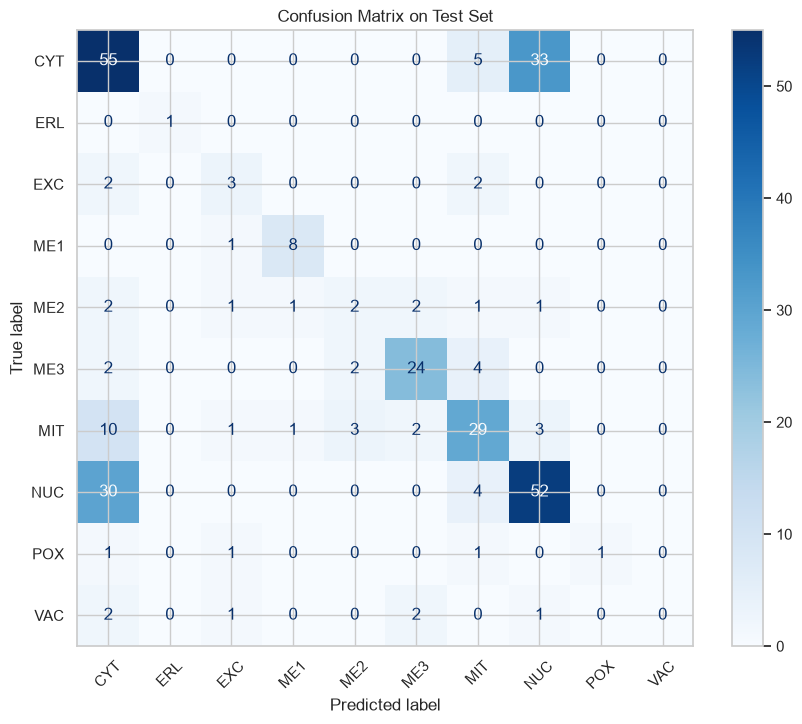

In [55]:
# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


#  Predict on test data
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test)
    y_pred_labels = torch.argmax(y_pred_logits, dim=1).cpu().numpy()


# convert ground truth to numpy from tensors
y_test_np = y_test.cpu().numpy()


# accuracy
acc = accuracy_score(y_test_np, y_pred_labels)
print(f"Test Accuracy: {acc:.4f}")


# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_labels)


# assuming you used LabelEncoder before
from sklearn.preprocessing import LabelEncoder

# re-create encoder and fit to original labels if needed
encoder = LabelEncoder()
encoder.fit(df['localization_site'])   # ensure same order as before
class_names = encoder.classes_


# show the class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()